In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
#Load database
payroll = pd.read_csv('gusto_payroll_bc.csv')

In [3]:
payroll.head()

,Employee_ID,Employee_Name,Role,Pay_Date,Gross_Pay,Federal_Tax,Provincial_Tax,CPP,EI,Other_Deductions,Net_Pay,Employer_CPP,Employer_EI,Tips,Travel_Reimbursement
0,1,Alice Johnson,Owner,2022-01-07,2002.24,240.27,100.11,119.13,32.64,0,1510.09,119.13,45.69,0.0,0.0
1,1,Alice Johnson,Owner,2022-01-21,1985.98,238.32,99.30,118.17,32.37,0,1497.82,118.17,45.32,0.0,0.0
2,1,Alice Johnson,Owner,2022-02-04,2081.15,249.74,104.06,123.83,33.92,0,1569.60,123.83,47.49,0.0,0.0
3,1,Alice Johnson,Owner,2022-02-18,1941.95,233.03,97.10,115.55,31.65,0,1464.62,115.55,44.32,0.0,0.0
4,1,Alice Johnson,Owner,2022-03-04,1989.04,238.69,99.45,118.35,32.42,0,1500.14,118.35,45.39,0.0,0.0


In [4]:
#15 columnas y 266 filas
payroll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee_ID           266 non-null    int64  
 1   Employee_Name         266 non-null    object 
 2   Role                  266 non-null    object 
 3   Pay_Date              266 non-null    object 
 4   Gross_Pay             266 non-null    float64
 5   Federal_Tax           266 non-null    float64
 6   Provincial_Tax        266 non-null    float64
 7   CPP                   266 non-null    float64
 8   EI                    266 non-null    float64
 9   Other_Deductions      266 non-null    int64  
 10  Net_Pay               266 non-null    float64
 11  Employer_CPP          266 non-null    float64
 12  Employer_EI           266 non-null    float64
 13  Tips                  266 non-null    float64
 14  Travel_Reimbursement  266 non-null    float64
dtypes: float64(10), int64(2

In [5]:
payroll.describe()

,Employee_ID,Gross_Pay,Federal_Tax,Provincial_Tax,CPP,EI,Other_Deductions,Net_Pay,Employer_CPP,Employer_EI,Tips,Travel_Reimbursement
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.0,266.000000,266.000000,266.000000,266.000000,266.000000
mean,3.067669,1486.885789,172.946880,71.604474,72.167556,19.770376,0.0,1150.397143,72.167556,27.678308,79.043571,14.661654
std,1.470184,270.559526,35.897325,15.395834,39.005294,10.685425,0.0,203.591752,39.005294,14.959670,96.221510,29.799300
min,1.000000,1123.230000,126.390000,50.560000,0.000000,0.000000,0.0,847.140000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1297.190000,148.187500,61.342500,72.942500,19.980000,0.0,979.537500,72.942500,27.972500,0.000000,0.000000
50%,3.000000,1397.825000,157.495000,65.625000,78.090000,21.395000,0.0,1123.025000,78.090000,29.950000,0.000000,0.000000
75%,4.000000,1531.110000,183.240000,76.347500,90.855000,24.890000,0.0,1227.255000,90.855000,34.847500,185.160000,0.000000
max,6.000000,2134.700000,256.160000,106.730000,127.010000,34.800000,0.0,1609.990000,127.010000,48.710000,284.500000,75.000000


In [6]:
payroll.isnull().sum()

Employee_ID             0
Employee_Name           0
Role                    0
Pay_Date                0
Gross_Pay               0
Federal_Tax             0
Provincial_Tax          0
CPP                     0
EI                      0
Other_Deductions        0
Net_Pay                 0
Employer_CPP            0
Employer_EI             0
Tips                    0
Travel_Reimbursement    0
dtype: int64

** Un hallazgo interesante del dataset es que no tiene ningun valor nulo.

In [7]:
#hare una copia del dataframe para no modificar el original
payroll_v2 = payroll.copy()

In [8]:
#Modificar el dataset para solo usar columnas especificas.
columns_to_use = ['Employee_Name', 'Role', 'Pay_Date', 'Gross_Pay',
                  'Net_Pay', 'Employer_CPP', 'Employer_EI', 'Tips',
                  'Travel_Reimbursement']
payroll_v2 = payroll_v2[columns_to_use]      

            

In [9]:
#columna pay_date es de tipo object, la convertiremos a datetime
payroll_v2['Pay_Date'] = pd.to_datetime(payroll_v2['Pay_Date'])

In [10]:
#normalizar los nombres de las columnas a minusculas
## es que me equivocaba mucho con las mayusculas, asi que mejor las paso a minusculas para evitar errores de tipeo PD: me altere de equivocarme con las columnas. 
payroll_v2.columns = payroll_v2.columns.str.lower() 
payroll_v2 = payroll_v2[[col.lower() for col in columns_to_use]]
payroll_v2.head()

,employee_name,role,pay_date,gross_pay,net_pay,employer_cpp,employer_ei,tips,travel_reimbursement
0,Alice Johnson,Owner,2022-01-07,2002.24,1510.09,119.13,45.69,0.0,0.0
1,Alice Johnson,Owner,2022-01-21,1985.98,1497.82,118.17,45.32,0.0,0.0
2,Alice Johnson,Owner,2022-02-04,2081.15,1569.60,123.83,47.49,0.0,0.0
3,Alice Johnson,Owner,2022-02-18,1941.95,1464.62,115.55,44.32,0.0,0.0
4,Alice Johnson,Owner,2022-03-04,1989.04,1500.14,118.35,45.39,0.0,0.0


In [11]:
#Costo real total para el empleador
payroll_v2['costo_real_empleador'] = (payroll_v2['gross_pay'] + 
                                      payroll_v2['employer_cpp'] + 
                                      payroll_v2['employer_ei']  +
                                      payroll_v2['travel_reimbursement'])
#Mes y año para agrupar temporalmente
payroll_v2['Mes'] = payroll_v2['pay_date'].dt.to_period('M')
# Porcentaje de deducción sobre el salario bruto
payroll_v2['% de deduccion'] = ((payroll_v2['gross_pay'] - payroll_v2['net_pay']) / payroll_v2['gross_pay'] * 100).round(2)

In [12]:
#Salario bruto promedio por empleado
print(payroll_v2.groupby('employee_name')['gross_pay'].mean().round(2))

employee_name
Alice Johnson    1998.34
Brian Smith      1301.45
Chloe Davis      1270.10
Daniel Lee       1496.02
Eva Thompson     1401.55
Frank White      1200.62
Name: gross_pay, dtype: float64


In [13]:
#Costo total por rol
print("Costo total por rol:" )
display(payroll_v2.groupby('role')['costo_real_empleador'].sum().round(2))

Costo total por rol:


role
Barista                   144728.42
Independent Contractor     72880.42
Manager                    88096.89
Owner                     112468.13
Seasonal Barista            7796.76
Name: costo_real_empleador, dtype: float64

In [14]:
#Propinas totales por empleado
print("Propinas totales por empleado:")
display(payroll_v2.groupby('employee_name')['tips'].sum().round(2))

Propinas totales por empleado:


employee_name
Alice Johnson        0.00
Brian Smith      10695.87
Chloe Davis       9300.17
Daniel Lee           0.00
Eva Thompson         0.00
Frank White       1029.55
Name: tips, dtype: float64

In [15]:

#Resumen mensual de nómina total
print("Resumen mensual de nómina total:")
display(payroll_v2.groupby('Mes')['gross_pay'].sum().round(2))

Resumen mensual de nómina total:


Mes
2022-01    15002.32
2022-02    14843.40
2022-03    15018.49
2022-04    22455.66
2022-05    14873.11
2022-06    17317.71
2022-07    17334.38
2022-08    17382.34
2022-09    22264.69
2022-10    14727.05
2022-11    14954.66
2022-12    14976.18
2023-01    15086.39
2023-02    14640.82
2023-03    22495.04
2023-04    14681.23
2023-05    14869.74
2023-06    15036.90
2023-07    15335.19
2023-08    14746.65
2023-09    22163.95
2023-10    15232.32
2023-11    14983.16
2023-12    15090.24
Freq: M, Name: gross_pay, dtype: float64

In [16]:
#resumen anual de nómina total
print("Resumen anual de nómina total:")
display(payroll_v2.groupby(payroll_v2['pay_date'].dt.year)['gross_pay'].sum().round(2))

Resumen anual de nómina total:


pay_date
2022    201149.99
2023    194361.63
Name: gross_pay, dtype: float64

In [17]:
#Promedio de % de deducción por rol
print("Promedio de % de deducción por rol:")
display(payroll_v2.groupby('role')['% de deduccion'].mean().round(2))

Promedio de % de deducción por rol:


role
Barista                   24.58
Independent Contractor    14.00
Manager                   24.58
Owner                     24.58
Seasonal Barista          24.58
Name: % de deduccion, dtype: float64

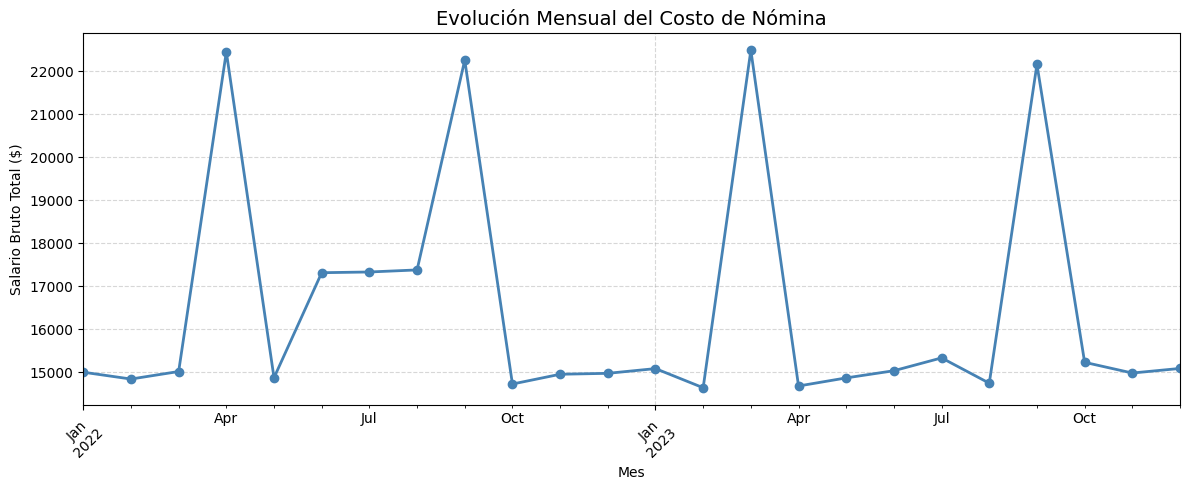

In [24]:
# Agrupar por mes
nomina_mensual = payroll_v2.groupby('Mes')['gross_pay'].sum()

fig, ax = plt.subplots(figsize=(12, 5))

nomina_mensual.plot(ax=ax, marker='o', color='steelblue', linewidth=2)

ax.set_title('Evolución Mensual del Costo de Nómina', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Salario Bruto Total ($)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('grafica1_evolucion_nomina.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Cómo evolucionó el costo total de nómina a lo largo del tiempo? ###

### La nómina mensual se mantiene relativamente estable entre $14,000 y $17,500, con picos notables en abril y septiembre de ambos años que superan los $22,000. Estos picos podrían explicarse por meses con tres períodos de pago quincenal o por contratación de personal temporal en temporadas de mayor demanda. El patrón se repite consistentemente en 2022 y 2023, lo que sugiere una estacionalidad en la operación del negocio.

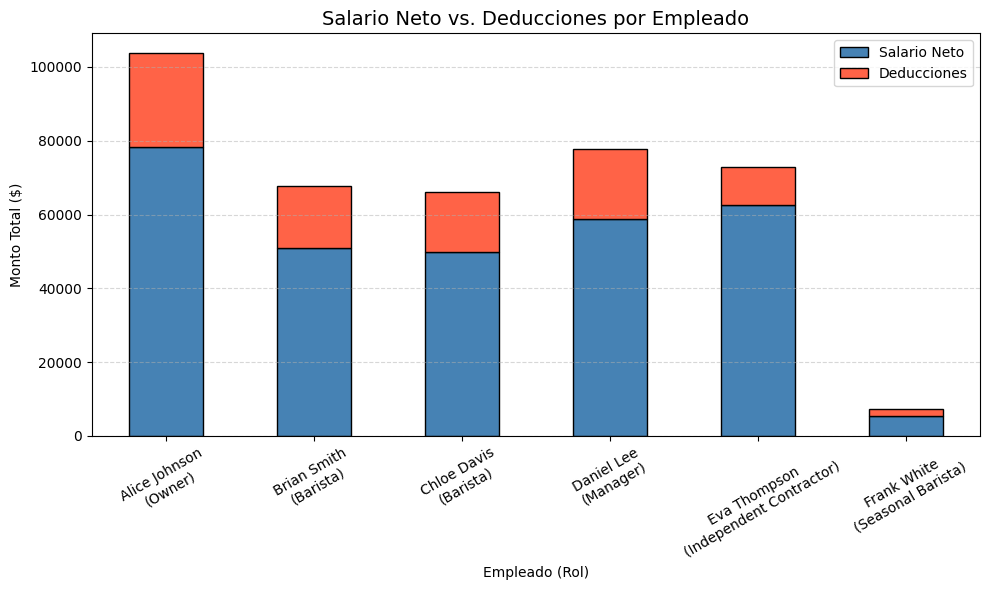

In [25]:
# Agrupar por empleado
resumen_emp = payroll_v2.groupby(['employee_name', 'role']).agg(
    Net_Pay=('net_pay', 'sum'),
    Deducciones=('gross_pay', lambda x: x.sum() - payroll_v2.loc[x.index, 'net_pay'].sum())
).round(2)

# Crear etiquetas combinadas "Nombre\n(Rol)"
resumen_emp.index = [f"{nombre}\n({rol})" for nombre, rol in resumen_emp.index]

fig, ax = plt.subplots(figsize=(10, 6))

resumen_emp.plot(kind='bar', stacked=True, ax=ax, 
                 color=['steelblue', 'tomato'], edgecolor='black')

ax.set_title('Salario Neto vs. Deducciones por Empleado', fontsize=14)
ax.set_xlabel('Empleado (Rol)')
ax.set_ylabel('Monto Total ($)')
ax.legend(['Salario Neto', 'Deducciones'])
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('grafica2_neto_vs_deducciones.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Cuánto representa el salario neto vs. las deducciones del salario bruto por empleado?

### Alice Johnson (Owner) representa el mayor costo de nómina total, superando los $100,000 acumulados en el período, y también tiene la mayor proporción de deducciones en términos absolutos. Daniel Lee (Manager) es el segundo más costoso, seguido de Eva Thompson (Independent Contractor). Los baristas Brian Smith y Chloe Davis tienen costos similares, siendo Brian ligeramente mayor. Frank White (Seasonal Barista) tiene la barra más pequeña, lo cual es consistente con su carácter temporal — solo trabajó una fracción del período total analizado. En general, la proporción de deducciones respecto al salario neto es visualmente similar entre todos los empleados, lo que indica una tasa de retención parecida independientemente del rol.

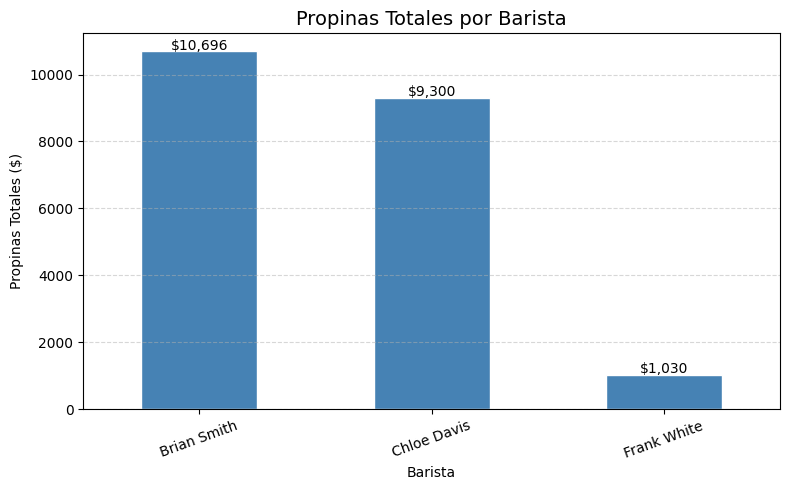

In [26]:
# Filtrar solo baristas y agrupar por empleado
propinas_baristas = payroll_v2[payroll_v2['role'].isin(['Barista', 'Seasonal Barista'])] \
                    .groupby('employee_name')['tips'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

propinas_baristas.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Propinas Totales por Barista', fontsize=14)
ax.set_xlabel('Barista')
ax.set_ylabel('Propinas Totales ($)')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Etiquetas encima de cada barra
for i, v in enumerate(propinas_baristas):
    ax.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('grafica3_propinas_baristas.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Qué empleados reciben más propinas y cuánto acumularon en el período?

### La diferencia entre Brian y Chloe es de aproximadamente $1,400, lo que podría explicarse por una mayor cantidad de horas trabajadas, turnos en horarios de mayor afluencia, o simplemente más períodos de pago registrados. Frank White, al ser barista estacional, acumuló apenas $1,030 en propinas, consistente con su participación limitada en el período analizado.

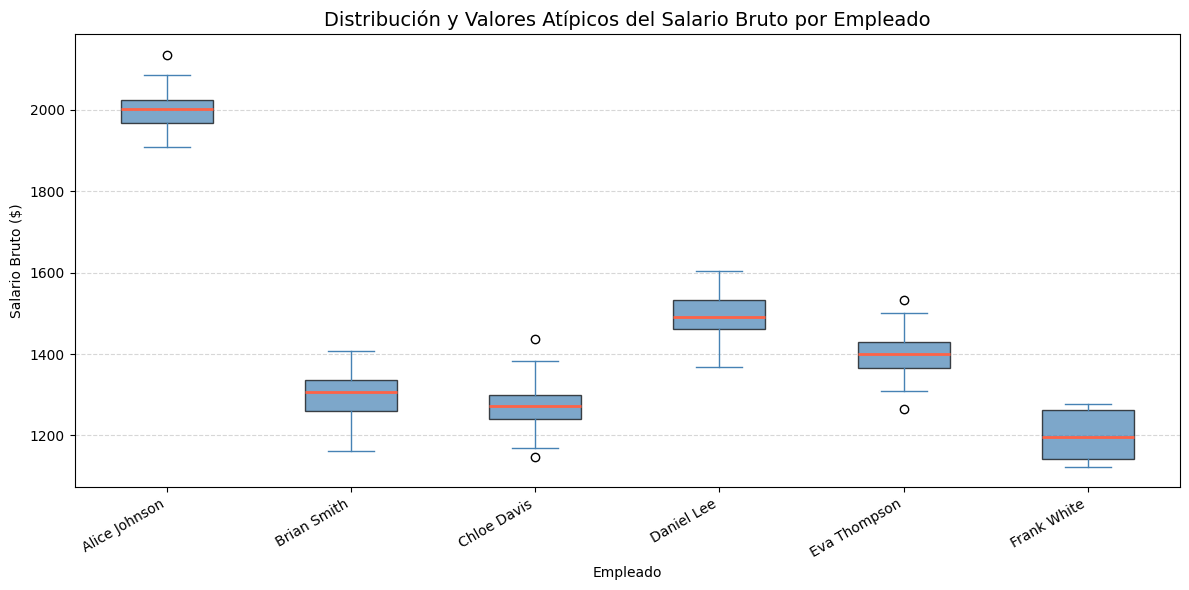

In [27]:
### boxplot de valores atípicos en Gross_Pay por empleado
fig, ax = plt.subplots(figsize=(12, 6))

# Preparar datos por empleado
empleados = payroll_v2['employee_name'].unique()
datos = [payroll_v2[payroll_v2['employee_name'] == emp]['gross_pay'].values 
         for emp in empleados]

bp = ax.boxplot(datos, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='tomato', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                flierprops=dict(marker='o', color='tomato', markersize=6))

ax.set_title('Distribución y Valores Atípicos del Salario Bruto por Empleado', fontsize=14)
ax.set_xlabel('Empleado')
ax.set_ylabel('Salario Bruto ($)')
ax.set_xticks(range(1, len(empleados) + 1))
ax.set_xticklabels(empleados, rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('grafica4_outliers_grosspay.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Hay valores atípicos en el Gross Pay por empleado?

### Se identificaron valores atípicos en tres empleados. Alice Johnson presenta un pago inusualmente alto ($2,134), que podría corresponder a un mes con tres períodos de pago o un bono puntual. Eva Thompson y Chloe Davis muestran tanto pagos atípicamente altos como atípicamente bajos, lo que sugiere variabilidad en sus horas trabajadas o ausencias en ciertos períodos. Los demás empleados — Brian Smith, Daniel Lee y Frank White — muestran distribuciones más consistentes y sin outliers, lo que indica una nómina más estable para sus roles. En el caso de Frank su caja indica la poca variacion en sus pagos, tiene sentido con su rol como barista temporal. 

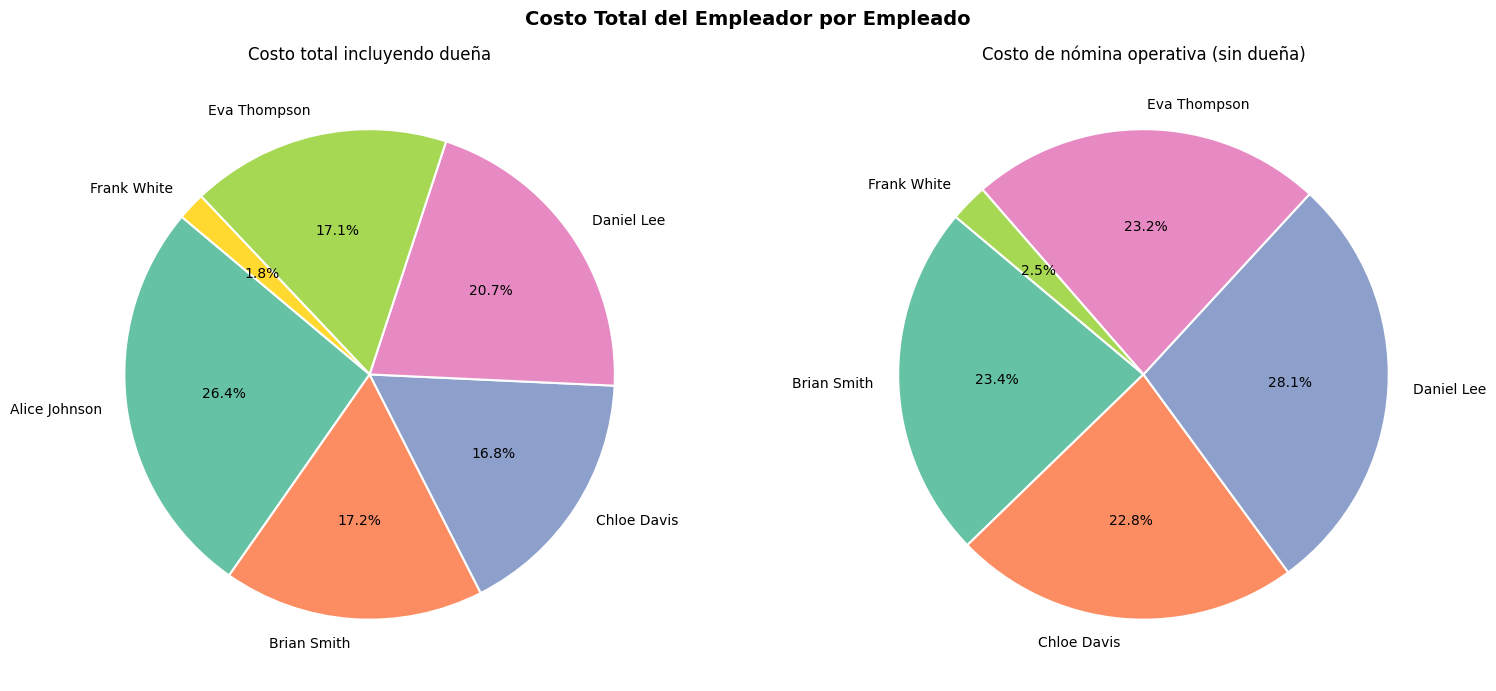

In [28]:
# Costo total por empleado
costo_emp = payroll_v2.groupby('employee_name')['costo_real_empleador'].sum().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Con Alice
costo_todos = payroll_v2.groupby('employee_name')['costo_real_empleador'].sum()

axes[0].pie(costo_todos, labels=costo_todos.index, autopct='%1.1f%%',
            colors=plt.cm.Set2.colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Costo total incluyendo dueña', fontsize=12)

# Sin Alice
costo_sin_alice = costo_todos[costo_todos.index != 'Alice Johnson']

axes[1].pie(costo_sin_alice, labels=costo_sin_alice.index, autopct='%1.1f%%',
            colors=plt.cm.Set2.colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Costo de nómina operativa (sin dueña)', fontsize=12)

fig.suptitle('Costo Total del Empleador por Empleado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica5_costo_empleador.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Cuál es el costo total real del empleador y cómo se distribuye entre empleados?

### En el grafico de la izquieda descubrimos el costo real total del negocio, desde una perspeectiva financiera, desde este punto Alice y Daniel son los costos mas altos de la operacion, seguidos de Eva, Brian y Chloe  y en el grafico de la derecha tenemos el costo operativo de la nomina que es mas util par tomar decisiones operativas. 

### Cruzando este análisis con los datos de propinas, los baristas Brian y Chloe representan juntos el 46.2% del costo operativo y a la vez generaron más de $20,000 en propinas acumuladas, lo que podría ser un indicador indirecto de su impacto positivo en la experiencia del cliente y en las ventas del negocio. Sin embargo, este indicador debe interpretarse con cautela ya que las propinas también dependen de factores externos como el volumen de clientes, la temporada y las preferencias individuales.



### Resumen final.

El dataset analizado corresponde a la nomina de un pequeño negocio  con 6 empleados y 5 roles distintos con registros quincenales entre enero 2022 y diciembre 2023 con un total de 266 registros. 

En el analisis no se encontraron valores nulos ni duplicados (que bendición!) y la unica columna sin información util fue Other_Deductions. 

Los hallazgos mas relevantes fueron: que la nomina mensual presenta una estacionalidad clara con picos recurrentes en abril y septiembre de ambos años, que pudieron estar asociados  con tres periodos de pagos  o mayor demanda. La dueña y el manager representan casi la midad del costo financiero del negocio. Las propinas son exclusivas de los baristas siendo Brian el que mas acumuló en el periodo.

Se hallaron valores atipicos en los pagos de Alice (dueña), Eva y Chloe, lo que sugiere variabilidad en sus horas o condiciones contractuales en ciertos periodos. Para terminar, al cruzar el costo operativo de los baristas con las propinas acumuladas se observa que estos empleados podrian tener un impacto positivo en la experiencia del cliente, aunque esto debe interpretarse con cuidado ya que intervienen factores externos fuera del control de los empleados.